# 16 — Convolution Intuition and Shapes

A fully connected network treats a flattened image as one long vector. A convolutional network instead preserves the image grid and learns filters that detect local patterns at every spatial position.

This notebook develops the geometry and shape reasoning needed before implementing a complete convolution layer.

## Learning objectives

- represent image batches as four-dimensional tensors;
- explain local connectivity and parameter sharing;
- calculate convolution output dimensions from kernel size, stride, and padding;
- understand how channels and filters determine output depth;
- compare convolutional and fully connected parameter counts;
- distinguish the operation used by CNN libraries from mathematical convolution;
- reason about receptive fields across multiple layers.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=2, suppress=True)

## 1. Images are spatial tensors

A color image has height, width, and channel dimensions. Image-loading libraries often use **channels last**:

$$
(H, W, C).
$$

In this CNN section, our NumPy layers will use **channels first** and include a batch dimension:

$$
X:(N,C,H,W).
$$

$N$ is the number of images, $C$ the number of channels, and $H,W$ the spatial dimensions. CIFAR-10 therefore arrives as $(N,32,32,3)$ but will be rearranged to $(N,3,32,32)$. Rearranging axes preserves every value and is different from flattening.

### Exercise 1 — Rearrange image axes

Convert the small channels-last batch to channels-first format using `np.transpose`. Do not use `reshape`: reshaping would reinterpret the existing order rather than move each axis to its new role.

In [6]:
images_nhwc = np.arange(2 * 4 * 5 * 3).reshape(2, 4, 5, 3)

# move the channel axis from the last position to the second position.
images_nchw = np.transpose(images_nhwc, axes=(0, 3, 1, 2))

assert images_nchw.shape == (2, 3, 4, 5)
assert images_nchw[1, 2, 3, 4] == images_nhwc[1, 3, 4, 2]
print("NHWC:", images_nhwc.shape, "-> NCHW:", images_nchw.shape)

NHWC: (2, 4, 5, 3) -> NCHW: (2, 3, 4, 5)


In [47]:
images_nhwc.shape, images_nchw.shape

((2, 4, 5, 3), (2, 3, 4, 5))

## 2. A filter sees a local receptive field

A convolutional filter does not connect to the entire image. At one output location it looks at a small spatial patch, multiplies corresponding entries, sums them, and adds a bias. For a single-channel input and a $3\times3$ filter:

$$
y_{i,j}=\sum_{u=0}^{2}\sum_{v=0}^{2}x_{i+u,j+v}w_{u,v}+b.
$$

The filter then slides to another location. The **same weights** are reused at every location. This is parameter sharing. It allows one learned pattern, such as an edge, to be detected in different parts of an image.

### Exercise 2 — Calculate one filter response

Select the top-left $3\times3$ patch and calculate its response as the sum of the elementwise product with `vertical_filter`. Use bias zero. Then visualize the input, selected patch, and filter.

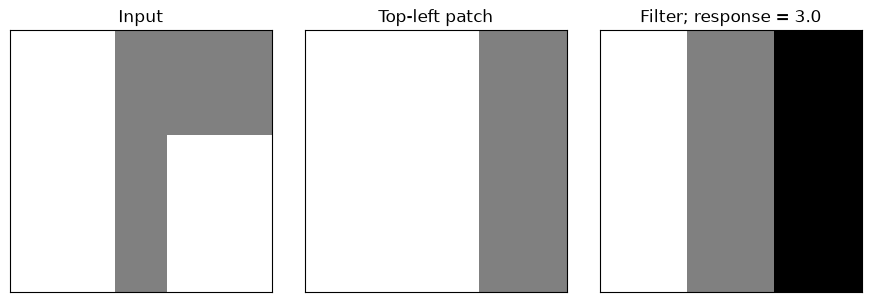

In [ ]:
small_image = np.array(
    [
        [1, 1, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 0, 1, 1],
        [1, 1, 0, 1, 1],
        [1, 1, 0, 1, 1],
    ],
    dtype=np.float64,
)
vertical_filter = np.array(
    [[1, 0, -1], [1, 0, -1], [1, 0, -1]],
    dtype=np.float64,
)

#  extract rows 0:3 and columns 0:3.
top_left_patch = small_image[:3, :3]
#  compute the scalar dot product between patch and filter.
response = np.vdot(top_left_patch, vertical_filter)

assert top_left_patch.shape == (3, 3)
assert np.isscalar(response)
assert np.isclose(response, 3.0)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for axis, array, title in zip(
    axes,
    (small_image, top_left_patch, vertical_filter),
    ("Input", "Top-left patch", f"Filter; response = {response:.1f}"),
):
    axis.imshow(array, cmap="gray", vmin=-1, vmax=1)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
plt.tight_layout()
plt.show()

In [25]:
np.vdot(top_left_patch, vertical_filter)

np.float64(3.0)

### Convolution or cross-correlation?

Mathematical convolution flips the filter before sliding it over the input. Neural-network libraries normally do not flip the filter; they compute **cross-correlation**. The operation is nevertheless called convolution in deep learning. Because the filter values are learned, the distinction does not reduce the model's expressive power. Our implementation will follow the deep-learning convention and will not flip filters.

## 3. Stride, padding, and output dimensions

For an input height $H$, filter height $HH$, zero-padding $P$, and stride $S$, the output height is

$$
H_{out}=1+\left\lfloor\frac{H+2P-HH}{S}\right\rfloor.
$$

Similarly,

$$
W_{out}=1+\left\lfloor\frac{W+2P-WW}{S}\right\rfloor.
$$

Why these terms appear:

1. Padding changes the usable height from $H$ to $H+2P$.
2. A filter of height $HH$ can start no later than position $H+2P-HH$.
3. Dividing by stride counts how many jumps fit between the first and last possible starts.
4. Adding one includes the first position at index zero.

The floor means a final partial window is discarded. In our later implementation, we will usually require exact tiling instead, so `(H + 2P - HH) % S == 0`.

### Exercise 3 — Implement output-shape calculation

Complete the helper. Reject impossible filters and configurations that do not tile the padded input exactly. Return only the two spatial dimensions.

In [ ]:
def convolution_output_shape(
    input_height,
    input_width,
    filter_height,
    filter_width,
    padding,
    stride,
):
    """Return (output_height, output_width) for an exactly tiled convolution."""
    # calculate the two available travel distances after padding.
    height_travel = input_height + 2*padding - filter_height
    width_travel = input_width + 2*padding - filter_width

    # validate positive stride, nonnegative travel, and exact tiling.
    if not isinstance(stride, (int, np.integer)) or isinstance(stride, (bool, np.bool_)) or stride <= 0:
        raise ValueError("stride must be a positive integer")
    if height_travel < 0 or width_travel < 0:
        raise ValueError("Nonnegative travel required")
    if height_travel % stride != 0 or width_travel % stride != 0:
        raise ValueError("Exact tiling required")

    # include the initial filter position in both dimensions.
    output_height = 1 + height_travel // stride
    output_width = 1 + width_travel // stride
    return output_height, output_width


assert convolution_output_shape(5, 5, 3, 3, padding=0, stride=1) == (3, 3)
assert convolution_output_shape(5, 5, 3, 3, padding=1, stride=1) == (5, 5)
assert convolution_output_shape(7, 9, 3, 3, padding=1, stride=2) == (4, 5)
print("Output-shape checks passed.")

Output-shape checks passed.


### Exercise 4 — Explain three configurations

Without running code first, calculate the output spatial shape for each case. Then use your helper to verify the answers. Add a short explanation of how padding and stride changed each result.

1. Input $8\times8$, filter $3\times3$, padding $0$, stride $1$.
2. Input $8\times8$, filter $3\times3$, padding $1$, stride $1$.
3. Input $9\times9$, filter $3\times3$, padding $1$, stride $2$.

- 1 + (8 + 2*0 - 3) / 1
- 1 + (8 + 2*1 - 3) / 1
- 1 + (9 + 2*1 - 3) / 2

$1+\frac{8-3}{1}=6,$

$1+\frac{8+2-3}{1}=8,$

$1+\frac{9+2-3}{2}=5.$

In [32]:
# write the three expected tuples before calling the helper.
expected_shapes = [(6,6), (8,8), (5,5)]

configurations = [
    (8, 8, 3, 3, 0, 1),
    (8, 8, 3, 3, 1, 1),
    (9, 9, 3, 3, 1, 2),
]
calculated_shapes = [convolution_output_shape(*config) for config in configurations]
assert calculated_shapes == expected_shapes
calculated_shapes

[(6.0, 6.0), (8.0, 8.0), (5.0, 5.0)]

## 4. Channels, filters, and output depth

A filter must span the full depth of its input. If the input has $C$ channels and the spatial filter size is $HH\times WW$, one filter has shape

$$
(C,HH,WW).
$$

It combines all channels at one spatial location and produces one scalar. A layer with $F$ filters has weights

$$
W:(F,C,HH,WW)
$$

and one bias per filter, $b:(F,)$. The complete output is

$$
Y:(N,F,H_{out},W_{out}).
$$

Thus the number of filters—not the number of input channels—determines output depth.

### Exercise 5 — Compute a multi-channel response

At one spatial position, multiply the complete $(C,HH,WW)$ patch by one filter, sum over all three axes, and add the filter's scalar bias.

In [35]:
patch = np.array(
    [
        [[1, 2], [3, 4]],
        [[0, 1], [0, 1]],
        [[2, 0], [1, 0]],
    ],
    dtype=np.float64,
)
one_filter = np.array(
    [
        [[1, 0], [0, -1]],
        [[1, 1], [1, 1]],
        [[-1, 0], [1, 0]],
    ],
    dtype=np.float64,
)
bias = 0.5

# sum over channels and both spatial dimensions, then add bias.
multi_channel_response = np.vdot(patch, one_filter) + bias

assert np.isscalar(multi_channel_response)
assert np.isclose(multi_channel_response, -1.5)
multi_channel_response

np.float64(-1.5)

## 5. Parameter sharing

A convolutional layer has

$$
F(C\cdot HH\cdot WW+1)
$$

learnable parameters. The `+1` is one bias for each filter. Notice that input height and width do not appear: moving a filter to another position reuses its parameters.

By contrast, an affine layer mapping a flattened input of size $D$ to $M$ outputs has

$$
DM+M
$$

parameters. Every output has a separate connection to every input value.

### Exercise 6 — Compare parameter counts

For CIFAR-10 input $(3,32,32)$, compare:

- an affine layer from all 3,072 pixels to 32 outputs;
- a convolutional layer with 32 filters of spatial size $3\times3$.

Include biases in both counts and calculate how many times larger the affine count is.

In [38]:
# include one bias for each of the 32 outputs or filters.
affine_parameters = 3072*32 + 32
convolution_parameters = 32*(3*3*3+1)
parameter_ratio = affine_parameters/convolution_parameters

assert affine_parameters == 98_336
assert convolution_parameters == 896
assert np.isclose(parameter_ratio, affine_parameters / convolution_parameters)
print(f"Affine: {affine_parameters:,}")
print(f"Convolution: {convolution_parameters:,}")
print(f"Ratio: {parameter_ratio:.1f}x")

Affine: 98,336
Convolution: 896
Ratio: 109.8x


## 6. Receptive fields grow with depth

One unit in the first convolutional layer sees only its local input patch. A unit in a later layer combines several earlier units, so it indirectly sees a larger part of the original image.

Let $R_l$ be receptive-field size and $J_l$ the spacing, measured in original input pixels, between adjacent features at layer $l$. Starting with $R_0=1$ and $J_0=1$:

$$
R_l=R_{l-1}+(K_l-1)J_{l-1},
$$

$$
J_l=J_{l-1}S_l.
$$

For stride-one layers, each $3\times3$ convolution adds two pixels to the receptive-field width: one layer sees $3\times3$, two see $5\times5$, and three see $7\times7$. This is one reason several small filters can replace one large filter while inserting more nonlinearities.

### Exercise 7 — Track a receptive field

A network applies these operations in order:

1. $3\times3$ convolution with stride 1;
2. $2\times2$ pooling with stride 2;
3. $3\times3$ convolution with stride 1.

Starting from $R=1$ and $J=1$, update both values after each operation. Store `(R, J)` after each layer.

In [46]:
operations = [(3, 1), (2, 2), (3, 1)]  # (kernel size, stride)
receptive_field = 1
jump = 1
receptive_field_history = []

for kernel_size, stride in operations:
    # update receptive_field before updating jump.
    receptive_field += (kernel_size - 1)*jump
    jump = stride*jump
    receptive_field_history.append((receptive_field, jump))

assert receptive_field_history == [(3, 1), (4, 2), (8, 2)]
receptive_field_history

[(3, 1), (4, 2), (8, 2)]

### Interpreting `(8, 2)`

The tuple `(8, 2)` does **not** describe an $8\times2$ receptive field. It means:

- each final feature sees an $8\times8$ region of the original image;
- adjacent final features are spaced by 2 pixels in the original image.

In one dimension, neighboring outputs might see input positions `0–7`, `2–9`, and `4–11`. Each region is eight pixels wide, but moving one position in the feature map shifts the region by two original pixels. The regions therefore overlap.

The jump became 2 at the stride-2 pooling layer:

```text
input                           jump = 1
3x3 convolution, stride 1      jump = 1 x 1 = 1
2x2 pooling, stride 2          jump = 1 x 2 = 2
3x3 convolution, stride 1      jump = 2 x 1 = 2
```

Thus the receptive field tells us **how much of the original image one feature sees**, while the jump tells us **how far that receptive field moves when we move by one feature-map position**.

## Reflection

Add a Markdown cell answering:

1. What information is lost when an image is flattened for an affine layer?
2. What is local connectivity?
3. What is parameter sharing, and why is it useful for images?
4. Why does one color-image filter span all input channels?
5. What determines the number of output channels?
6. Why does the output-size formula contain `+1`?
7. What happens when stride increases?
8. How can padding preserve spatial size for an odd filter and stride 1?
9. Why does a convolutional layer usually need far fewer parameters than a comparable affine layer?
10. Why do CNN implementations call cross-correlation convolution?
11. How can deeper units see a larger part of the original image?
12. Which part of convolution shape reasoning is still least clear?

The next notebook will turn this geometry into a naive convolution forward pass with explicit NumPy loops.

1. spacial stuff like position, edges, shapes, corners, etc. Flattening does not delete pixel values, but it removes the explicit spatial organization from the representation. The affine layer is not told which pixels are neighbors.
2. Local connectivity means one convolution output is connected only to a small spatial region of the input, rather than to every input value.
3. same filter goes throught full image and calculate next layer channel. More precisely: the same filter weights are applied at every spatial location, allowing the same pattern to be detected anywhere. One filter produces one output feature map.
4. A filter spans all input channels because one output feature should combine all features available at that spatial location. For an RGB image, it can therefore detect patterns involving combinations of red, green, and blue.
5. the number of filters determines the number of output channels.
6. The +1 counts the initial filter placement at position zero. The division counts the number of movements after that initial placement
7. output shape decreases. A larger stride evaluates fewer spatial positions, normally reducing output height and width.
8. it is +2*P in formula. 
precise result. For an odd $K\times K$ filter and stride 1, use:
$P=\frac{K-1}{2}.$ For a $3\times3$ filter, this gives $P=1$.
9. cause same filter used across image. Convolution uses local connections and reuses the same filter parameters at every location, so parameter count does not grow with the number of spatial positions.
10. CNN libraries normally calculate cross-correlation: they slide the filter without flipping it. Mathematical convolution flips the filter first. Deep learning conventionally calls both operations convolution.
11. receptive field increases with each next layer. a later unit combines several neighboring earlier units, and each of those already depends on a region of the preceding layer. Their input regions combine into a larger receptive field.
12. Initially I confused (8, 2) with an $8\times2$ receptive field. It actually means an $8\times8$ receptive field and a jump of 2.

$8\times8$